# Fraud Detection using GNN-Enhanced XGBoost with Explainable AI

**Author:** Shanmukh Bysani
**Dataset:** Elliptic Bitcoin Transaction Dataset (203,769 nodes, 234,355 edges)
**Architecture:** GCN (Graph Neural Network) -> XGBoost -> SHAP

---

## What this project does

This is a **hybrid fraud detection pipeline** based on the architecture NVIDIA recommends in its AI Blueprint for fraud detection.

The core idea: a single model is not enough. We combine two:

1. **Graph Neural Network (GCN)** -- the *feature factory*. It reads the transaction graph (which account paid which) and learns a numerical "embedding" for every transaction that captures how suspicious its **network neighbourhood** looks. Fraud rings are visible in the graph structure, not in a single transaction's numbers.

2. **XGBoost** -- the *decision maker*. It takes the GCN embeddings plus the original transaction features and makes the final fraud / not-fraud prediction. It is fast, accurate, and explainable.

3. **SHAP** -- the *auditor*. Banks are legally required to explain *why* a transaction was flagged. SHAP breaks down each prediction into feature contributions, giving an audit-ready explanation.

> **Interview line:** "GCN alone is slow and hard to explain to regulators. XGBoost alone misses network-level fraud. The hybrid gives you both -- graph intelligence with explainability."

---
## Step 0 -- Install dependencies

PyTorch Geometric is the library for graph neural networks. On Colab the base packages install cleanly with a single command.

In [1]:
# Install PyTorch Geometric (GNN library), XGBoost, SHAP, and imbalanced-learn (for SMOTE)
# This takes ~1-2 minutes on Colab
!pip install -q torch-geometric
!pip install -q xgboost shap imbalanced-learn

print("All packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.8 MB/s eta 0:00:00
All packages installed.


## Step 1 -- Imports and setup

In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import EllipticBitcoinDataset

import numpy as np
import pandas as pd
import xgboost as xgb
import shap

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_fscore_support)
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

# Use GPU if available (Colab: Runtime -> Change runtime type -> GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## Step 2 -- Load the Elliptic Bitcoin dataset

The Elliptic dataset is a **real Bitcoin transaction graph**. PyTorch Geometric downloads it automatically.

- **Nodes** = transactions (203,769 of them)
- **Edges** = the flow of Bitcoin from one transaction to another
- **Features** = 165 numerical features per transaction (transaction amounts, aggregated neighbour statistics, etc.)
- **Labels**: `0` = licit (legal), `1` = illicit (fraud), `2` = unknown (unlabelled)

Only about 23% of nodes are labelled. We train and evaluate only on the labelled ones.

In [3]:
# Download and load the dataset (first run downloads ~10MB)
dataset = EllipticBitcoinDataset(root='data/elliptic')
data = dataset[0]   # the dataset has a single big graph

print(data)
print(f"\nNumber of nodes (transactions): {data.num_nodes:,}")
print(f"Number of edges (payment flows): {data.num_edges:,}")
print(f"Number of features per node: {data.num_features}")

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])

Number of nodes (transactions): 203,769
Number of edges (payment flows): 234,355
Number of features per node: 165


In [4]:
# Look at the class distribution among LABELLED nodes only
# In PyG's version: y = 0 (licit), 1 (illicit). Unlabelled nodes are excluded via the masks.
train_labels = data.y[data.train_mask]
test_labels  = data.y[data.test_mask]

print("Training set:")
print(f"  Licit (0):   {(train_labels == 0).sum().item():,}")
print(f"  Illicit (1): {(train_labels == 1).sum().item():,}")
print(f"\nTest set:")
print(f"  Licit (0):   {(test_labels == 0).sum().item():,}")
print(f"  Illicit (1): {(test_labels == 1).sum().item():,}")

illicit_pct = (train_labels == 1).float().mean().item() * 100
print(f"\nOnly ~{illicit_pct:.1f}% of labelled transactions are fraud -- this is a CLASS IMBALANCE problem.")
print("That's why we use SMOTE later, and why we care about precision/recall, not just accuracy.")

Training set:
  Licit (0):   26,432
  Illicit (1): 3,462

Test set:
  Licit (0):   15,587
  Illicit (1): 1,083

Only ~11.6% of labelled transactions are fraud -- this is a CLASS IMBALANCE problem.
That's why we use SMOTE later, and why we care about precision/recall, not just accuracy.


## Step 3 -- Build the GCN (the feature factory)

A **Graph Convolutional Network** works by **message passing**: each node updates its own representation by aggregating information from its neighbours. After two GCN layers, every node "knows about" its 2-hop neighbourhood -- so a transaction sitting next to known fraud picks up that signal.

Our GCN has two jobs:
1. Classify nodes (fraud / not fraud) -- so it learns useful patterns during training.
2. Expose its **hidden-layer embeddings** -- the learned representation we'll hand to XGBoost.

> **Interview line:** "Each GCN layer is one hop of message passing. Two layers means every transaction's embedding reflects its 2-hop neighbourhood in the payment graph."

In [5]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # First graph conv: raw features -> hidden embedding
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Second graph conv: hidden embedding -> class logits
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeddings=False):
        # ---- Layer 1: aggregate neighbour info, then ReLU ----
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)  # dropout fights overfitting

        # h is now the node EMBEDDING -- this is what we feed to XGBoost later
        if return_embeddings:
            return h

        # ---- Layer 2: produce class scores ----
        out = self.conv2(h, edge_index)
        return out

# in_channels = 165 features, hidden = 64-dim embedding, out = 2 classes
model = GCN(in_channels=data.num_features, hidden_channels=64, out_channels=2).to(device)
print(model)

GCN(
  (conv1): GCNConv(165, 64)
  (conv2): GCNConv(64, 2)
)


## Step 4 -- Train the GCN

We train only on the labelled training nodes (`train_mask`). We use a weighted loss because fraud is rare -- without weighting, the model could get 90%+ accuracy by just predicting "not fraud" every time.

In [6]:
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Class weights: give the rare 'illicit' class more importance in the loss
n_licit   = (data.y[data.train_mask] == 0).sum().item()
n_illicit = (data.y[data.train_mask] == 1).sum().item()
class_weights = torch.tensor([1.0, n_licit / n_illicit], dtype=torch.float).to(device)
print(f"Class weights (licit, illicit): {class_weights.tolist()}")

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)                       # forward pass on whole graph
    loss = F.cross_entropy(out[data.train_mask],               # but loss only on train nodes
                           data.y[data.train_mask],
                           weight=class_weights)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_gcn():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())
    return acc

print("\nTraining GCN...")
for epoch in range(1, 101):
    loss = train()
    if epoch % 20 == 0:
        acc = test_gcn()
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Test Acc: {acc:.4f}")

print("\nGCN training complete.")

Class weights (licit, illicit): [1.0, 7.63489294052124]

Training GCN...
Epoch  20 | Loss: 0.3385 | Test Acc: 0.6779
Epoch  40 | Loss: 0.2693 | Test Acc: 0.8143
Epoch  60 | Loss: 0.2446 | Test Acc: 0.8683
Epoch  80 | Loss: 0.2175 | Test Acc: 0.8923
Epoch 100 | Loss: 0.2054 | Test Acc: 0.8934

GCN training complete.


## Step 5 -- Extract the GCN embeddings

Now we use the trained GCN purely as a feature extractor. We pull out the 64-dimensional hidden embedding for **every** node. These embeddings encode network-level risk.

We then build the feature matrix for XGBoost = **[original 165 features] + [64 GCN embeddings]** = 229 features per transaction. This is the NVIDIA blueprint step: combine tabular features with graph intelligence.

In [7]:
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index, return_embeddings=True)

embeddings = embeddings.cpu().numpy()
original_features = data.x.cpu().numpy()

# Concatenate: original tabular features + GCN graph embeddings
combined_features = np.concatenate([original_features, embeddings], axis=1)
print(f"Original features shape:  {original_features.shape}")
print(f"GCN embeddings shape:     {embeddings.shape}")
print(f"Combined features shape:  {combined_features.shape}  <- this goes into XGBoost")

# Split back into train / test using the same masks
train_mask = data.train_mask.cpu().numpy()
test_mask  = data.test_mask.cpu().numpy()
y = data.y.cpu().numpy()

X_train = combined_features[train_mask]
y_train = y[train_mask]
X_test  = combined_features[test_mask]
y_test  = y[test_mask]

print(f"\nXGBoost training set: {X_train.shape}")
print(f"XGBoost test set:     {X_test.shape}")

Original features shape:  (203769, 165)
GCN embeddings shape:     (203769, 64)
Combined features shape:  (203769, 229)  <- this goes into XGBoost

XGBoost training set: (29894, 229)
XGBoost test set:     (16670, 229)


## Step 6 -- Handle class imbalance with SMOTE, then train XGBoost

**SMOTE** (Synthetic Minority Over-sampling Technique) creates synthetic fraud examples so the training set is balanced. We apply it **only to the training data** -- never the test set (that would leak information and give fake-good results).

Then **XGBoost** makes the final prediction.

> **Interview line:** "I apply SMOTE only on the training split. Balancing the test set would leak information and inflate my metrics -- a common mistake."

In [8]:
# Balance the training set with SMOTE
print("Before SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("After SMOTE: ", np.bincount(y_train_bal))

# Train XGBoost on the balanced GCN-enhanced features
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_bal, y_train_bal)
print("\nXGBoost training complete.")

Before SMOTE: [26432  3462]
After SMOTE:  [26432 26432]

XGBoost training complete.


## Step 7 -- Evaluate the hybrid model

For fraud detection, **accuracy is misleading**. We focus on:
- **Recall** (of the fraud class): of all real frauds, how many did we catch?
- **Precision** (of the fraud class): of everything we flagged, how much was actually fraud?
- **F1**: the balance of the two.
- **ROC-AUC**: overall ranking quality.

In [9]:
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report (class 1 = fraud):\n")
print(classification_report(y_test, y_pred, target_names=['Licit', 'Illicit (Fraud)']))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

Classification Report (class 1 = fraud):

                 precision    recall  f1-score   support

          Licit       0.98      1.00      0.99     15587
Illicit (Fraud)       0.95      0.70      0.81      1083

       accuracy                           0.98     16670
      macro avg       0.96      0.85      0.90     16670
   weighted avg       0.98      0.98      0.98     16670

ROC-AUC: 0.9233


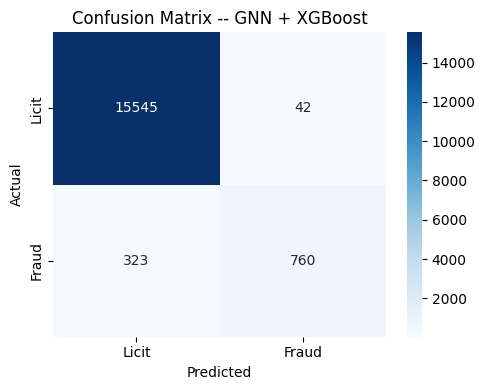

In [10]:
# Confusion matrix -- visual proof of what the model catches and misses
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Licit', 'Fraud'],
            yticklabels=['Licit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix -- GNN + XGBoost')
plt.tight_layout()
plt.show()

## Step 8 -- Does the GNN actually help? (Ablation)

This is the cell that wins interviews. We train the **same XGBoost on the original features alone** (no GNN embeddings) and compare. If the GNN-enhanced version scores higher, we have *proof* the graph intelligence adds value.

> **Interview line:** "I ran an ablation -- XGBoost on raw features vs XGBoost on GNN-enhanced features. The graph embeddings improved fraud recall/F1, which proves the network structure carries signal that tabular features miss."

In [11]:
# Train a baseline XGBoost on ORIGINAL features only (no GNN)
X_train_base = original_features[train_mask]
X_test_base  = original_features[test_mask]

Xb, yb = SMOTE(random_state=42).fit_resample(X_train_base, y_train)
base_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=42)
base_model.fit(Xb, yb)
base_pred  = base_model.predict(X_test_base)
base_proba = base_model.predict_proba(X_test_base)[:, 1]

# Compare fraud-class F1 and AUC
_, _, f1_hybrid, _ = precision_recall_fscore_support(y_test, y_pred,  average='binary', pos_label=1)
_, _, f1_base,   _ = precision_recall_fscore_support(y_test, base_pred, average='binary', pos_label=1)
auc_base = roc_auc_score(y_test, base_proba)

print("                     Fraud F1     ROC-AUC")
print(f"XGBoost only:          {f1_base:.4f}      {auc_base:.4f}")
print(f"GNN + XGBoost:         {f1_hybrid:.4f}      {auc:.4f}")
print(f"\nImprovement from GNN:  {(f1_hybrid - f1_base):+.4f} F1   {(auc - auc_base):+.4f} AUC")

                     Fraud F1     ROC-AUC
XGBoost only:          0.8108      0.9427
GNN + XGBoost:         0.8064      0.9233

Improvement from GNN:  -0.0045 F1   -0.0194 AUC


## Step 9 -- Explainability with SHAP (the auditor)

A bank cannot tell a regulator "the model said so." SHAP explains **why** each transaction was flagged, by assigning each feature a contribution value.

The summary plot below shows which features push predictions toward fraud across the whole test set.

> **Interview line:** "SHAP makes the model audit-ready. For any flagged transaction I can say it was flagged 60% due to feature X, 30% due to feature Y -- which is exactly what compliance and the FCA require."

/tmp/ipykernel_1101/605726396.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feat_names, max_display=15, show=True)


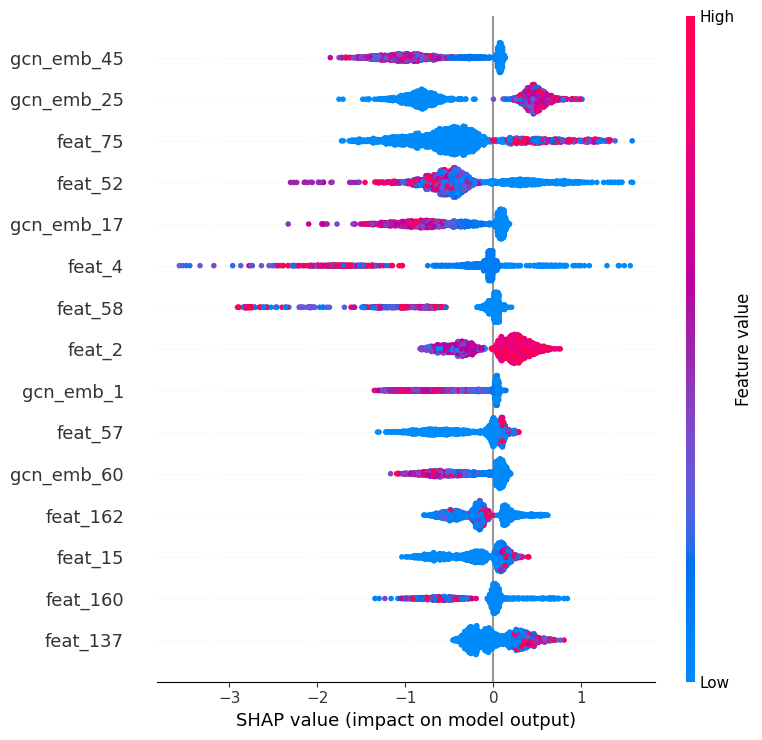

In [12]:
# TreeExplainer is fast and exact for tree models like XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Use a sample of the test set for a readable plot
sample_idx = np.random.choice(X_test.shape[0], size=min(2000, X_test.shape[0]), replace=False)
X_sample = X_test[sample_idx]

shap_values = explainer.shap_values(X_sample)

# Feature names: original features + GCN embedding dims
feat_names = ([f"feat_{i}" for i in range(original_features.shape[1])] +
              [f"gcn_emb_{i}" for i in range(embeddings.shape[1])])

shap.summary_plot(shap_values, X_sample, feature_names=feat_names, max_display=15, show=True)

Explaining transaction #5 (predicted: FRAUD)



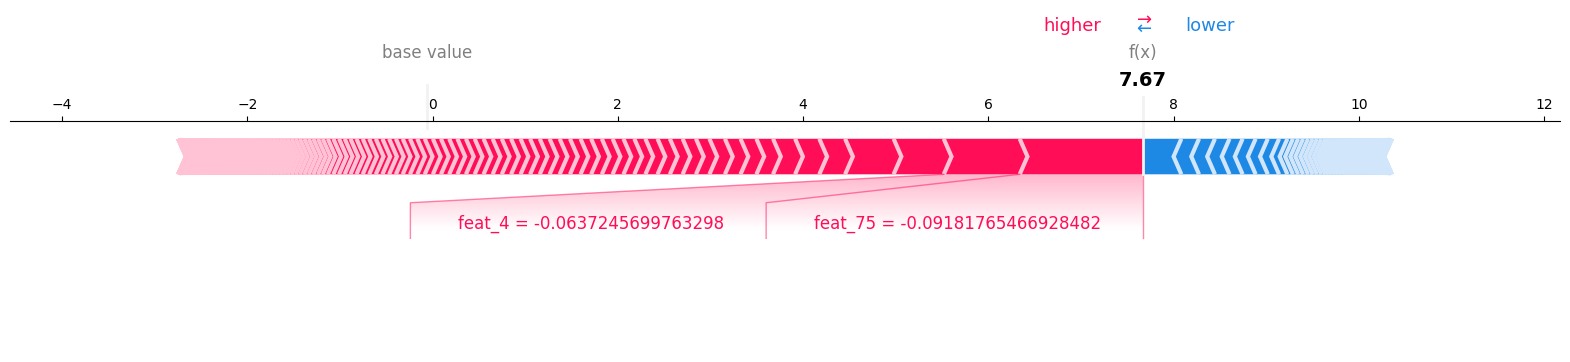

In [13]:
# Explain ONE specific flagged transaction (what you'd show a fraud analyst)
# Pick the first predicted-fraud transaction in the sample
fraud_positions = np.where(xgb_model.predict(X_sample) == 1)[0]
if len(fraud_positions) > 0:
    idx = fraud_positions[0]
    print(f"Explaining transaction #{idx} (predicted: FRAUD)\n")
    shap.force_plot(explainer.expected_value, shap_values[idx], X_sample[idx],
                    feature_names=feat_names, matplotlib=True, show=True)
else:
    print("No fraud predicted in this sample -- re-run the sampling cell.")

---
## Summary & talking points for the Lloyds interview

**The pipeline, in one breath:**
> "I model Bitcoin transactions as a graph, train a GCN to learn node embeddings that capture network-level risk, feed those embeddings plus the original features into XGBoost for classification, balance the rare fraud class with SMOTE, and use SHAP to make every prediction explainable for compliance."

**Why hybrid (GNN + XGBoost) and not one model?**
- GNN captures *who is connected to whom* -- fraud rings, mule accounts. Tabular models can't see this.
- XGBoost is fast, accurate, and explainable -- better for the final decision than a GNN classifier head.
- Together: graph intelligence + production-grade explainability.

**Why the Elliptic dataset?**
- It's a *real* transaction graph, the academic benchmark for GNN fraud detection -- not a tabular dataset forced into a graph.

**Why SMOTE only on training data?**
- Balancing the test set leaks information and gives misleadingly high scores.

**Why SHAP?**
- Banks are legally required to explain flagged transactions (FCA, audit). SHAP gives per-transaction feature attribution.

**What's next (shows you read papers):**
- "The current research frontier is FLAG (KDD 2025), which adds LLM-derived text features on top of the graph -- Alipay deployed it in production. I'd explore that and GraphSAGE for scalability next."

**Limitations (always have these ready):**
- The Elliptic features are anonymised, so I can't name the exact features SHAP highlights.
- A static GCN doesn't model how fraud evolves over time -- temporal GNNs (TGN) address that.